# Visualizer Notebook
### Just a helper notebook/snippets to print out images in NIFTI format
### As part of the Deep Learning course project

#### Background:
MRI images need to be stored in a non-compressable format so as not to cause any data loss nor require computational power to be read on the very weak medical devices whose hardware might not handle de-compressing large images.
Images should hold medical metadata.

The two widely used image formats are 1- DICOM (.dcm) and 2- NIFTI (.nii or .nii.gz)

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import time
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob


# the one library to handle nii images
import nibabel as nib

In [ ]:
IMAGE_TYPE = "4CH" #Available types are 2CH, 4CH and SAX

# I just made some boilerplate that reads directories based on the type of images
# Just change any path you want, but consider the aftermath of doing so (I hate my spaghetti coding skills)
DATASET_FOLDER_NAME = f"CMR-MULTI\\CINE_MULTI\\{IMAGE_TYPE}_TR\\image"
LABEL_FOLDER_NAME = f"CMR-MULTI\\CINE_MULTI\\{IMAGE_TYPE}_TR\\anno"

PATH_DATASET = os.path.join(os.getcwd(), DATASET_FOLDER_NAME)
PATH_LABEL = os.path.join(os.getcwd(), LABEL_FOLDER_NAME)

Example_Train_NII_Path = os.path.join(PATH_DATASET, f"CINE_{IMAGE_TYPE}_005.nii.gz")
Example_Label_NII_Path = os.path.join(PATH_LABEL, f"CINE_{IMAGE_TYPE}_005.nii.gz")

I will just make a lable dictionary so that the labels make sense when they are drawn on the images

In [14]:
LBLS_2CH = {0: "[0] none", 1 : "[1] Left Ventricle Cavity", 2: "[2] Left Ventricle Myocardium"}
LBLS_4CH = {0: "[0] none", 1 : "[1] Left Ventricle Cavity", 2 : "[2] Left Ventricle Myocardium", 3 : "[3] Right Ventricle Cavity", 4 : "[4] Right Atrium", 5 : "[5] Left Atrium"}
LBLS_SAX = {0: "[0] none", 1 : "[1] Left Ventricle Myocardium", 2 : "[2] Left Ventricle Cavity", 3 : "[3] Right Ventricle Cavity"}

label_dict = {"2CH" : LBLS_2CH, "4CH": LBLS_4CH, "SAX" : LBLS_SAX}

current_labels = label_dict[IMAGE_TYPE] #We'll use this dictionary as a lookup for description of each label.

In [15]:
Example_Reading_Train_NII = nib.load(Example_Train_NII_Path)
Example_Reading_Label_NII = nib.load(Example_Label_NII_Path)

print(type(Example_Reading_Train_NII))
print(Example_Reading_Train_NII) # general info

<class 'nibabel.nifti1.Nifti1Image'>

<class 'nibabel.nifti1.Nifti1Image'>
data shape (149, 144, 225)
affine:
[[-1.03131282e+00  4.43441123e-01  1.96929142e-01 -3.02208042e+01]
 [-8.73521388e-01 -3.97650778e-01 -2.50154108e-01  1.67869919e+02]
 [-9.52757522e-02 -1.15422928e+00  1.61839992e-01  5.44019699e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 149 144 225   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.        1.3548886 1.29885   0.3571419 1.        1.        1.
 1.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : 

In [16]:
print(Example_Reading_Train_NII.get_data_dtype()) #Notice that data is stored as float not integers

print(Example_Reading_Train_NII.get_filename()) # Just printing the full path as a sanity check

float32
c:/Users/ayman.mohamed/Personal/Masters_Security/Deep_Learning/CMR-MULTI/CINE_MULTI/SAX_TR/image/CINE_SAX_005.nii.gz


In [17]:
print(Example_Reading_Train_NII.get_fdata()) # This is the actual image pixels, returned as numpy array

[[[   3.08137584    4.08682871    7.91002512 ...    4.00545311
      4.89660215    6.75272655]
  [   4.58137608    5.65226507    7.87730694 ...    4.07088947
      4.17932034    3.78544474]
  [   7.01887608    6.64114952    6.5241189  ...    5.49223995
      4.77747488    4.44861555]
  ...
  [1045.25170898 1044.99182129 1041.46472168 ...  360.06796265
    374.30410767  380.79342651]
  [1111.33154297 1107.84631348 1101.01318359 ...  359.29342651
    372.60046387  374.85110474]
  [1170.12097168 1167.12390137 1159.73718262 ...  365.16506958
    371.52578735  369.73196411]]

 [[   2.25587249    3.3645134     6.20742464 ...    4.10864115
      4.12269306    6.80432034]
  [   3.75587249    6.16820478    5.55557871 ...    5.41233206
      4.02453852    4.45616627]
  [   6.19337225    5.76405191    4.61514282 ...    7.71078014
      6.48007536    5.84165287]
  ...
  [ 947.11999512  952.58703613  949.73071289 ...  360.17114258
    372.962677    380.43225098]
  [1004.06774902 1006.77368164 1006.

### Dimensions
Each nii.gz file is 1 image (having a height and width), and it has multiple channels (depth)

the image is 3d image, having width, height and depth.

Sometimes, they call the depth by "slices"

In [18]:
print(Example_Reading_Train_NII.get_fdata().shape) # Dimensions

(149, 144, 225)


In [19]:
Example_ALL_Images = Example_Reading_Train_NII.get_fdata()
Example_ALL_Labels = Example_Reading_Label_NII.get_fdata()

[Text(1, 0, '[0] none'),
 Text(1, 1, '[1] Left Ventricle Myocardium'),
 Text(1, 2, '[2] Left Ventricle Cavity'),
 Text(1, 3, '[3] Right Ventricle Cavity')]

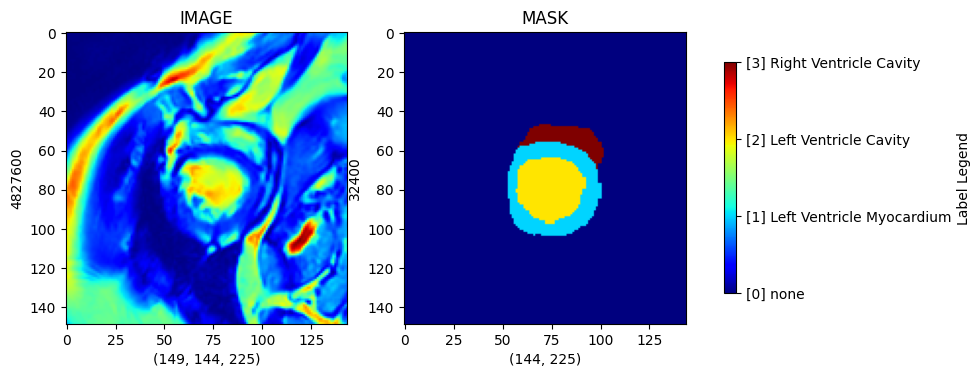

In [20]:
figure,axis = plt.subplots(1,2,figsize=(10,10))

axis[0].imshow(Example_ALL_Images[:, :, Example_ALL_Images.shape[0]//2],cmap="jet")
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

Plot_Color_Op = axis[1].imshow(Example_ALL_Labels[:, :, Example_ALL_Images.shape[0]//2],cmap="jet")
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size)
axis[1].set_title("MASK")

cbar = figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=list(current_labels.keys()), label='Label Legend')
cbar.ax.set_yticklabels(list(current_labels.values()))

[Text(1, 0, '[0] none'),
 Text(1, 1, '[1] Left Ventricle Myocardium'),
 Text(1, 2, '[2] Left Ventricle Cavity'),
 Text(1, 3, '[3] Right Ventricle Cavity')]

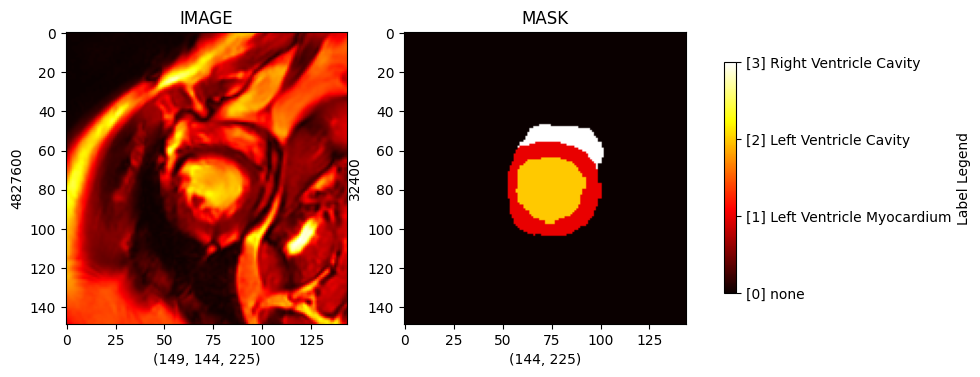

In [21]:
figure,axis = plt.subplots(1,2,figsize=(10,10))

axis[0].imshow(Example_ALL_Images[:, :, Example_ALL_Images.shape[0]//2],cmap="hot")
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

Plot_Color_Op = axis[1].imshow(Example_ALL_Labels[:, :, Example_ALL_Images.shape[0]//2],cmap="hot")
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Images.shape[0]//2].size)
axis[1].set_title("MASK")

cbar = figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=list(current_labels.keys()), label='Label Legend')
cbar.ax.set_yticklabels(list(current_labels.values()))

[Text(1, 0, '[0] none'),
 Text(1, 1, '[1] Left Ventricle Myocardium'),
 Text(1, 2, '[2] Left Ventricle Cavity'),
 Text(1, 3, '[3] Right Ventricle Cavity')]

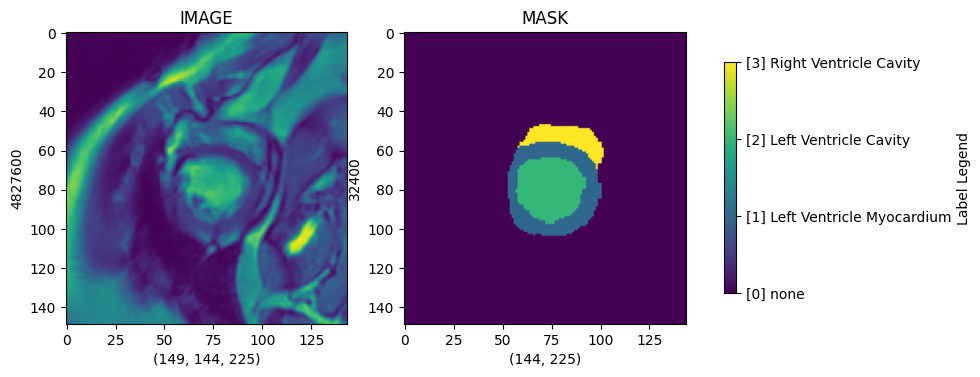

In [22]:
figure,axis = plt.subplots(1,2,figsize=(10,10))

axis[0].imshow(Example_ALL_Images[:, :, Example_ALL_Images.shape[0]//2])
axis[0].set_xlabel(Example_ALL_Images.shape)
axis[0].set_ylabel(Example_ALL_Images.size)
axis[0].set_title("IMAGE")

Plot_Color_Op = axis[1].imshow(Example_ALL_Labels[:, :, Example_ALL_Labels.shape[0]//2])
axis[1].set_xlabel(Example_ALL_Labels[Example_ALL_Labels.shape[0]//2].shape)
axis[1].set_ylabel(Example_ALL_Labels[Example_ALL_Labels.shape[0]//2].size)
axis[1].set_title("MASK")

cbar = figure.colorbar(Plot_Color_Op, ax=axis.ravel().tolist(), shrink=0.3, ticks=list(current_labels.keys()), label='Label Legend')
cbar.ax.set_yticklabels(list(current_labels.values()))